In [4]:
import sklearn.metrics as metrics

# Dataset clásico de clasificación (3 clases de flores)
from sklearn.datasets import load_iris

# Regresión logística → clasificación binaria o multiclase
from sklearn.linear_model import LogisticRegression

# Herramientas de validación y partición
from sklearn.model_selection import (
    cross_val_predict,  # predicciones por validación cruzada
    cross_val_score,    # score por validación cruzada
    train_test_split,   # partición hold-out
    KFold               # partición en K bolsas
)

# Preprocesamiento (estandarización, normalización...)
from sklearn import preprocessing

# Funciones personalizadas de evaluación y visualización - esto lo tenemos en local
from evaluacion_funciones import *

In [5]:
# Carga de datos.
datos = load_iris()
X = datos.data[:,2:] # Utilizamos solo 2 atributos.
y = datos.target
print(np.shape(X))

(150, 2)


In [6]:
# Métricas de evaluación.
metricas = {
  'ACC':    metrics.accuracy_score,
  'PREC':   lambda y_true, y_pred:
            metrics.precision_score(y_true, y_pred, average='micro'),
  'RECALL': lambda y_true, y_pred:
            metrics.recall_score(y_true, y_pred, average='micro'),
  'F1':     lambda y_true, y_pred:
            metrics.f1_score(y_true, y_pred, average='micro')}

In [7]:
# 1) Partición de datos externa
 # partición hold-out 80/20
 # La semilla (random_state) fija el generador de números aleatorios para que el resultado sea siempre el mismo.
X_training, X_testing, y_training, y_testing = train_test_split(X, y, test_size=0.2, random_state=42)
print(np.shape(X_training))

(120, 2)


In [ ]:
# ------------- TRAINING ---------------- #

In [ ]:
# 2) Extracción de características

In [8]:
# 3) Estandarización de los datos de entrenamiento
standardizer = preprocessing.StandardScaler()
X_stdr = standardizer.fit_transform(X_training)
# print(X_stdr)

In [ ]:
# 4) Selección de atributos

In [10]:
# 5) Construcción del algoritmo de aprendizaje.
algoritmos = {
    'LOGR': LogisticRegression(
        penalty='l1',           # regularización L1 (Lasso) → fuerza algunos pesos a 0 (selección de features)
        solver='saga',          # algoritmo de optimización (necesario para L1 con multiclase)
        max_iter=1000,          # máximo de iteraciones para converger
        random_state=42,        # semilla para reproducibilidad
        multi_class='ovr'       # One-vs-Rest: entrena un clasificador binario por cada clase
    )
}

In [11]:
# 5.1) VALIDACIÓN CRUZADA INTERNA

y_pred = {}  # diccionario vacío para guardar predicciones de cada modelo

for nombre, alg in algoritmos.items():
    # Obtener predicciones por validación cruzada de 10 bolsas
    y_pred[nombre] = cross_val_predict(alg, X_stdr, y_training,
                                       cv=KFold(n_splits=10, shuffle=True, random_state=42))

    # Calcular métricas comparando predicciones vs valores reales
    results = evaluacion(y_training, y_pred[nombre], metricas)

    # Matriz de confusión: muestra aciertos y errores por clase
    print(metrics.confusion_matrix(y_training, y_pred[nombre]))
    print(results)

# ALTERNATIVA más simple (solo accuracy):
# results = cross_val_score(alg, X_stdr, y_training,
#                           cv=KFold(n_splits=10, shuffle=True, random_state=42))
# print("Accuracy:   %0.4f +/- %0.4f" % (results.mean(), results.std()))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

[[40  0  0]
 [ 1 37  3]
 [ 0  5 34]]
{'ACC': 0.925, 'PREC': 0.925, 'RECALL': 0.925, 'F1': 0.925}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/content/evaluacion_funciones.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, cmap=plt.cm.Paired,


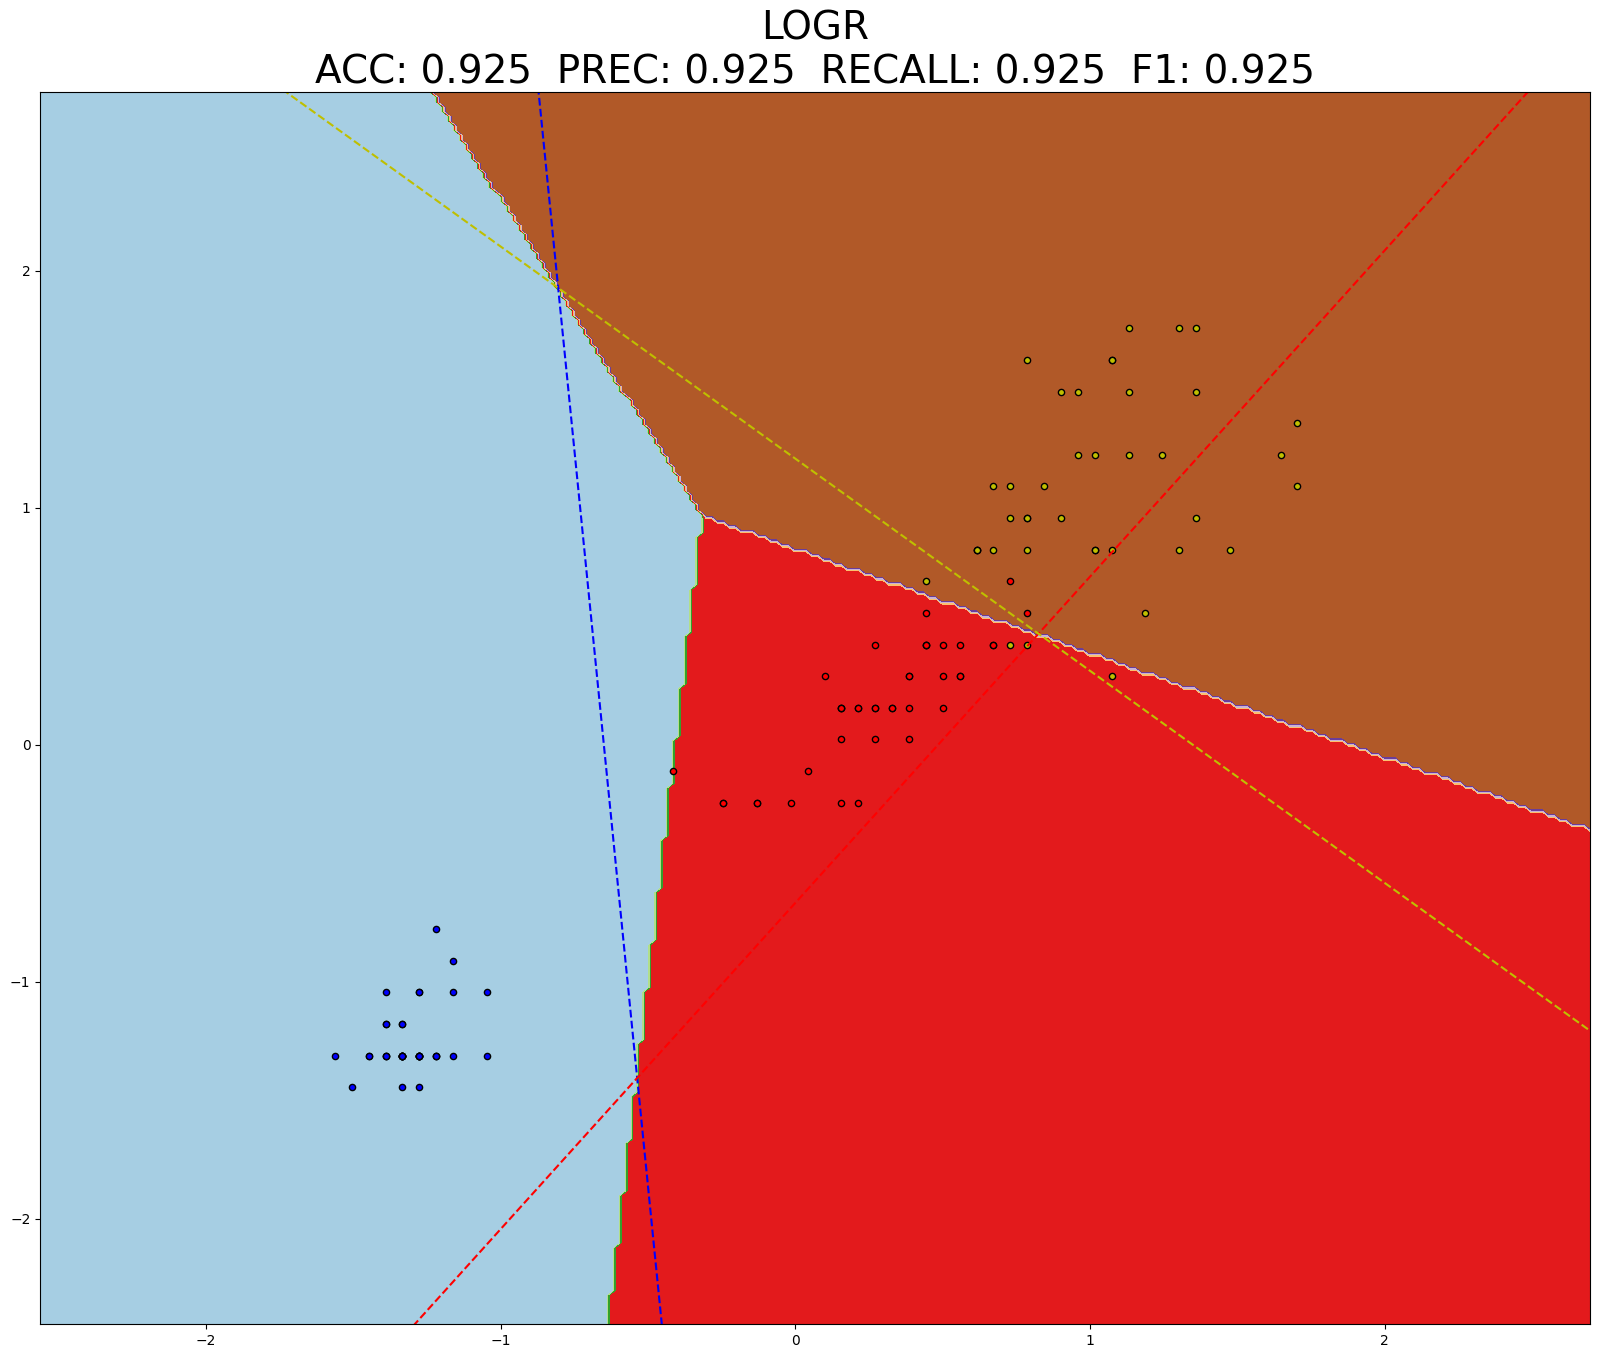

In [12]:
# 5.2) Entrenamiento del modelo definitivo
model = algoritmos['LOGR'].fit(X_stdr, y_training)

# Visualización de las fronteras de decisión
mapa_modelo_clasif_2d(X_stdr, y_training, model, results, nombre)

In [ ]:
# ------------- PREDICTION ---------------- #

In [ ]:
# 6) Extracción de las características de test

In [13]:
# 7) Estandarización de las característiacs de test
X_test_stdr = standardizer.transform(X_testing)

In [ ]:
# 8) Selección de los atributos de test

In [19]:
# 9) PREDICCIÓN SOBRE EL CONJUNTO DE TEST

# model       → debe ser el modelo ya entrenado con .fit() en el paso anterior
# X_test_stdr → X_testing estandarizado con el scaler entrenado en training
y_pred_test = model.predict(X_test_stdr)
print(y_pred_test)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [21]:
# 10) EVALUACIÓN FINAL SOBRE EL CONJUNTO DE TEST

# Calcular métricas comparando predicciones vs valores reales del test
results = evaluacion(y_testing, y_pred_test, metricas)
print(results)

# Matriz de confusión sobre el test
print(metrics.confusion_matrix(y_testing, y_pred_test))

{'ACC': 1.0, 'PREC': 1.0, 'RECALL': 1.0, 'F1': 1.0}
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


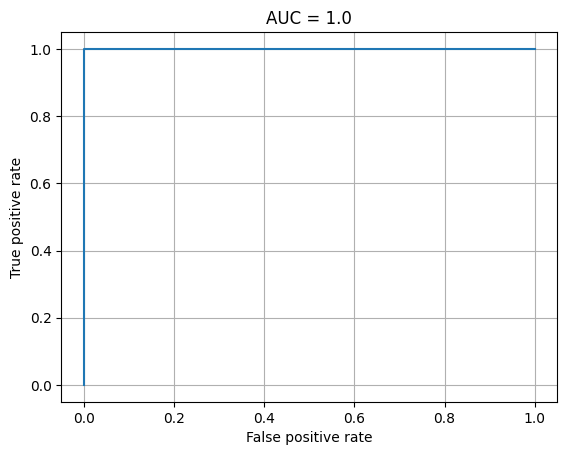

In [22]:
# CURVA ROC PARA CLASIFICACIÓN MULTICLASE

# predict_proba devuelve probabilidades para cada clase en vez de la clase directamente
# resultado: matriz (n_muestras, n_clases) → cada fila suma 1
y_proba_test = model.predict_proba(X_test_stdr)

# label_binarize convierte las etiquetas multiclase a formato binario (One-vs-Rest)
# Iris: [0,1,2] → cada muestra se convierte en vector [1,0,0], [0,1,0] o [0,0,1]
y_test_bin = preprocessing.label_binarize(y_testing, classes=[0, 1, 2])

# Calcular AUC para problema multiclase con estrategia OvR
# multi_class='ovr' → calcula AUC para cada clase vs el resto y promedia
auc = metrics.roc_auc_score(y_testing, y_proba_test, multi_class='ovr')

# Calcular FPR y TPR solo para la clase 1 (columna 1)
# th → umbrales usados para construir la curva
fpr, tpr, th = metrics.roc_curve(y_test_bin[:,1], y_proba_test[:,1])

# Plotear la curva ROC
plt.plot(fpr, tpr)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('AUC = ' + str(np.round(auc, 4)))
plt.grid()
plt.show()

⚠️ La curva solo muestra la ROC de la clase 1 ([:,1]), pero el AUC es el promedio de las 3 clases. Para ver las 3 curvas habría que iterar sobre cada clase:

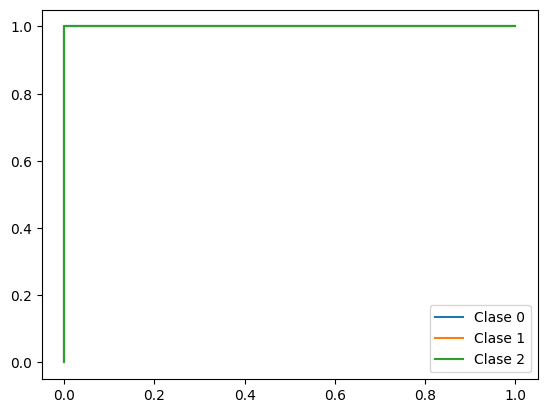

In [23]:
for i in range(3):
    fpr, tpr, _ = metrics.roc_curve(y_test_bin[:,i], y_proba_test[:,i])
    plt.plot(fpr, tpr, label=f'Clase {i}')
plt.legend()
plt.show()